# Kapitel 10

In [1]:
import math
from typing import Callable
def min1(f:Callable,x0:float,eps=0.000001)->float:
    delta=0.1
    while True: 
        if f(x0-delta)<f(x0): # Bewegung nach links
            x0-=delta; continue # Nächster Schritt
        if f(x0)>f(x0+delta): # Bewegung nach rechts
            x0+=delta; continue
        if delta<eps: break  
        delta=delta/2 # Verkleinere die Schrittweite
    return x0   
min1(math.cos,2.5)

3.1415924072265624

In [2]:
def abl1(f:Callable,x:float,h=0.00001)->float: # Approximation der ersten Ableitung
    return (f(x+h)-f(x-h))/(2*h)
def abl2(f:Callable,x:float,h=0.00001)->float: # Approximation der zweiten Ableitung
    return (abl1(f,x+h,h)-abl1(f,x-h,h))/(2*h)
def mini1abl(f:Callable,x0:float, eps=0.0000001)->float:
    while True:
        a=0.5*abl2(f,x0)
        b=abl1(f,x0)-x0*abl2(f,x0)
        x1=-b/(2*a)
        if abs(x1-x0)<eps: return x1
        x0=x1
mini1abl(math.cos,2.5)

3.1415926535901932

In [3]:
def istKlammer(f:Callable,K:list): 
   return f(K[0])>=f(K[1]) and f(K[1])<=f(K[2]) 
def verbessere(f:Callable,K:list)->list:     
    [a,b,c]=K     
    if not(istKlammer(f,K)): 
       raise Exception("Keine Klammer:"+str(K))
    if istKlammer(f,[(a+b)/2.0,b,c]):
        [a,b,c]=[(a+b)/2.0,b,c]
    if istKlammer(f,[a,b,(c+b)/2.0]):
        [a,b,c]=[a,b,(c+b)/2.0]      
    if istKlammer(f,[a,(a+b)/2.0,b]):         
        [a,b,c]=[a,(a+b)/2.0,b]     
    if istKlammer(f,[b,(b+c)/2.0,c]):         
        [a,b,c]=[b,(b+c)/2.0,c]     
    return [a,b,c]
def miniKlammer(f:Callable,K:list,eps=0.00000001):     
    while K[2]-K[0]>eps:         
        K=verbessere(f,K)
    return K[1]
print("miniKlammer:  startwert 1,2,5 : ",        miniKlammer(math.cos,[1,2,5]))

miniKlammer:  startwert 1,2,5 :  3.141592656262219


In [4]:
def f(x:float,y:float)->float: # Abstandssumme von (x,y) zu (1,3), (5,2) und (4,7)
    d1=math.sqrt((x-1)**2+(y-3)**2)
    d2=math.sqrt((x-5)**2+(y-2)**2)
    d3=math.sqrt((x-4)**2+(y-7)**2)
    return d1+d2+d3
def f2(v:list)->float:
    [x,y]=v
    d1=math.sqrt((x-1)**2+(y-3)**2)
    d2=math.sqrt((x-5)**2+(y-2)**2)
    d3=math.sqrt((x-4)**2+(y-7)**2)
    return d1+d2+d3
print(f(1,1),f2([1,1]))

12.831309558117031 12.831309558117031


In [5]:
def minN(f:Callable,x0:list, eps=0.000001)->list:
    delta=0.1 
    while True: 
        improved=False # Verbesserung gefunden? 
        for i in range(len(x0)):
            x1=x0[:] # Kopie 
            x1[i]=x0[i]+delta
            if f(x1)<f(x0):
                x0=x1; improved=True; continue 
            x1[i]=x0[i]-delta
            if f(x1)<f(x0):
                x0=x1; improved=True; continue
        if improved: continue
        if delta<eps: break
        delta=delta/2
    return x0
print('Min von f2: ', minN(f2,[5,5]) )  

Min von f2:  [3.219953918457034, 3.6708023071289095]


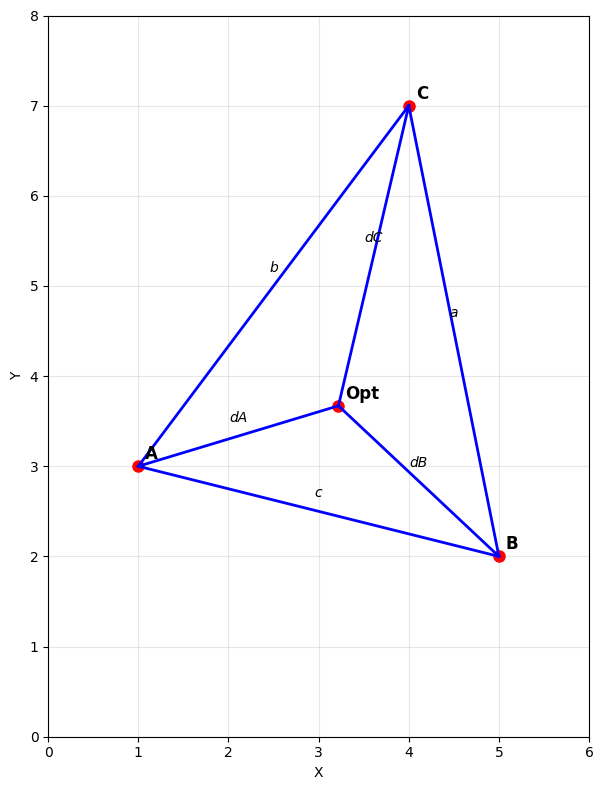

In [6]:
# Das Folgende zeichnet die Situation
import matplotlib.pyplot as plt
def plotGeo(points:list, lines:list, x0, y0, x1, y1):
    fig, ax = plt.subplots(figsize=(10, 8))
    point_dict = {name: coords for name, coords in points}
    for name, coords in points:
        x, y = coords
        ax.plot(x, y, 'ro', markersize=8)  # Blaue Kreise
        # Punktname etwas versetzt anzeigen
        ax.annotate(name, (x, y), xytext=(5, 5), textcoords='offset points', 
                   fontsize=12, fontweight='bold')
    for line_name, point_names in lines:
        start_point = point_dict[point_names[0]]
        end_point = point_dict[point_names[1]]
        ax.plot([start_point[0], end_point[0]], 
                [start_point[1], end_point[1]], 'b-', linewidth=2)
        mid_x = (start_point[0] + end_point[0]) / 2
        mid_y = (start_point[1] + end_point[1]) / 2
        ax.annotate(line_name, (mid_x, mid_y), xytext=(0, 10), 
                   textcoords='offset points', fontsize=10, 
                   ha='center', style='italic')
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

points = [["A", [1, 3]], ["B", [5, 2]], ["C", [4, 7]],["Opt",minN(f2,[5,5])]]  
lines = [["c", ["A", "B"]],["a", ["C", "B"]],["b", ["A", "C"]],
         ["dA",["A","Opt"]],["dB",["B","Opt"]],["dC",["C","Opt"]]]
plotGeo(points, lines, 0, 0, 6, 8)


In [7]:
# Gradient auf Basis der Vektoroperationen aus einer Übungsaufgabe zu Kap. 4
def vadd(a:list, b:list)->list:
    if len(a)!=len(b): # Die beiden Zeilen könnte man sich natürlich sparen, aber sicher ist sicher...
        raise Exception("vadd: Vektoren müssen gleiche Dim. haben")
    return [a[i]+b[i] for i in range(len(a))]
def vsub(a:list, b:list)->list:
    if len(a)!=len(b):
        raise Exception("vsub: Vektoren müssen gleiche Dim. haben")
    return [a[i]-b[i] for i in range(len(a))]
def smul(x:float, b:list)->list:
    return [x*b[i] for i in range(len(b))]
def skalarp(a:list, b:list)->float:
    if len(a)!=len(b):
        raise Exception("Skalarprodukt: Vektoren müssen gleiche Dim. haben")
    return sum([a[i]*b[i] for i in range(len(a))])
def betrag(v:list)->float:
    return math.sqrt(skalarp(v,v))

def deltav(n:int,i:int,a:float)->list[float]:
    v=[0]*n
    v[i]=a
    return v
def grad(f,x0:list[float],dx=0.0000001)->list[float]:
    n=len(x0)
    return [(f(vadd(x0,deltav(n,i,dx)))-f(vsub(x0,deltav(n,i,dx))))/(2*dx) for i in range(n)]    
grad(f2,[3,4])   

[-0.12890735590076474, 0.20563708069687436]

In [8]:
def miniparNg(f:Callable,x0:list,eps=0.00001,maxIter=1000)->list: 
    c=0
    while c<maxIter:
        c=c-1
        g=grad(f,x0)
        if betrag(g)<eps: 
            return x0
        mu=min1(lambda mu: f(vadd(x0,smul(mu,g))),0)
        x0=vadd(x0,smul(mu,g))
print("Minimum von f2test mit miniparNg: ", miniparNg(f2,[1,1]))

Minimum von f2test mit miniparNg:  [3.2199515430759624, 3.6707995516672316]


In [9]:
# Regressionsbeispiel
deg=math.pi/180
daten= [[0*deg,400],[10*deg,370],[20*deg,360],[45*deg,300],[60*deg,200],[80*deg,80]]
def fModell(para:list,x:float)->float:
    [a,b]=para
    return a*math.cos(x)+b
def QS(para:list)->float:
    return sum([(fModell(para,d[0])-d[1])**2 for d in daten])
minN(QS,[0,0])

[370.8855079651037, 18.873864746093762]

In [10]:
daten=[[3,1],[2,2],[1,3],[0,3],[-1,-2],[0,-2]]
def f(arg:list)->float:
    [xm,ym,r]=arg
    return sum([((x-xm)**2+(y-ym)**2-r**2)**2 for [x,y] in daten])
minN(f,[0,0,0])

[0.2856109619140625, 0.4135169982910157, 2.5988502502441415]

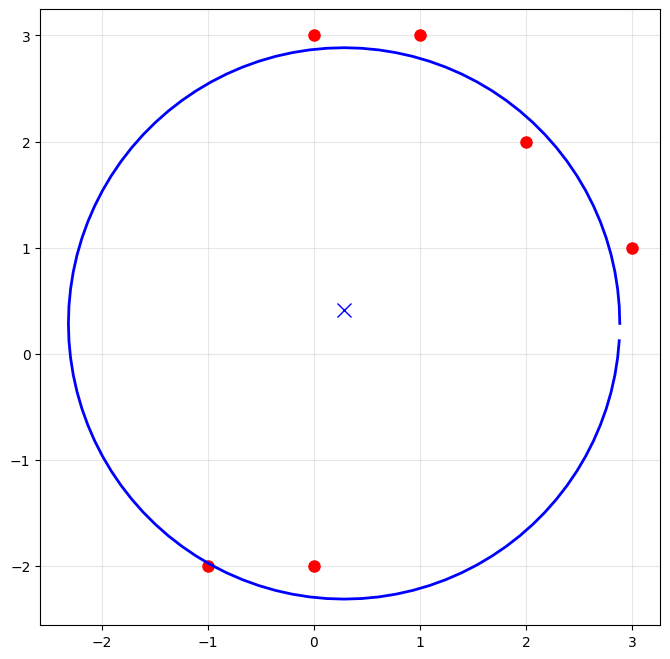

In [11]:
[xm,ym,r]=minN(f,[0,0,0])
import matplotlib.pyplot as plt
# Kreispunkte erstellen
x_kreis=[xm+r*math.cos(i/100*2*math.pi) for i in range(100)]
y_kreis=[xm+r*math.sin(i/100*2*math.pi) for i in range(100)]
plt.figure(figsize=(8, 8))
plt.plot([p[0] for p in daten], [p[1] for p in daten], 'ro', markersize=8, label='Punkte')
plt.plot(x_kreis, y_kreis, 'b-', linewidth=2, label='Kreis')
plt.plot(xm, ym, 'bx', markersize=10, label='Mittelpunkt')
# Achsen und Gitter
plt.grid(True, alpha=0.3); plt.axis('equal'); plt.show()

[[0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20], [8, 3.106449127197282, 2.2175628662109563, 1.4764289855957147, 0.8494735717773562, 0.31683044433595203, -0.1344543457031181, -0.5133300781249963, -0.8261962890624984, -1.0777084350585961, -1.2712562561035217, -1.4092582702636791, -1.493346405029304, -1.5244796752929743, -1.503005981445318, -1.4286865234375055, -1.3006774902343792, -1.117476654052737, -0.8768211364746091, -0.5755180358886721, -0.20917282104492263, 0]]


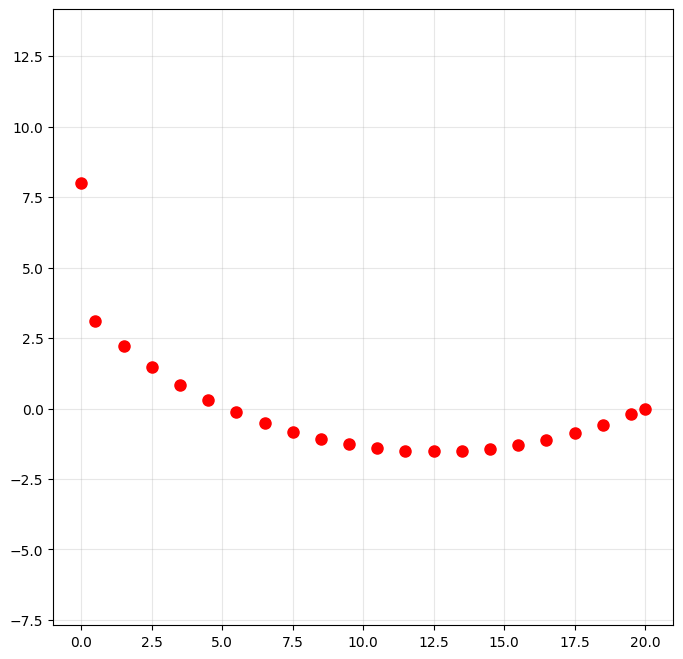

In [12]:
# Das Problem der Brachistochrone
def Zeit(xi:list,yi:list)->float: 
    # xi,yi sind Listen der Art xi=[x1,x2,...]
    # Ergebnis ist Gesamtzeit, wenn Anfangsgeschwindigkeit =0     
    t=0.0; g=9.81  # Erdbeschleunigung     
    for i in range(len(xi)-1):
        [xa,xb]=xi[i:i+2]
        [ya,yb]=yi[i:i+2]
        y=(ya+yb)/2 # Mittlere Höhe
        v=math.sqrt(2*g*(yi[0]-y)) # aus 1/2*m*v^2=m*g*h
        strecke=math.sqrt((xa-xb)**2+(ya-yb)**2)
        t+=strecke/v
    return t
def Brachisto(P:list,Q:list,n:int): 
    # P,Q sind Startkoordinaten     
    # Anfangsweg: Lineare Rutschbahn:
    xi=[P[0]]; yi=[P[1]]     
    for i in range(n):
        xi.append(P[0]+(Q[0]-P[0])/ n*(i+0.5))         
        yi.append(P[1]+(Q[1]-P[1])/n*(i+0.5))     
    xi.append(Q[0]); yi.append(Q[1])  # Endpunkt
    def f(Yinnen): # Nur die y-Werte im Inneren werden verändert
        return Zeit(xi,[yi[0]]+Yinnen+[yi[-1]])     
    yLsg=[yi[0]]+minN(f,yi[1:-1])+[yi[-1]]
    #yLsg=[yi[0]]+miniparNg(f,yi[1:-1])+[yi[-1]]
    return [xi,yLsg]
Lsg=Brachisto([0,8],[20,0],20)

print(Lsg)
plt.figure(figsize=(8, 8))
plt.plot(Lsg[0], Lsg[1], 'ro', markersize=8)
plt.grid(True, alpha=0.3); plt.axis('equal'); plt.show()

In [13]:
def miniNeben(f:Callable,g:Callable,x0,gewicht=10000,eps=1e-6): 
    # f wird minimiert unter der Nebenbedingung g=0
    return minN(lambda x: f(x)+gewicht*g(x)**2,x0,eps)
def fAbstand(P:list)->float: 
    return (P[0]**2+P[1]**2-3**2)**2 
def gKurve(P:list)->float: 
    return P[0]+P[1]-10 
print("Optimaler Punkt : ", miniNeben(fAbstand,gKurve,[5,4]))
def miniNebenAbs(f:Callable,g:Callable,x0,gewicht=1000,eps=1e-8): 
    # f wird minimiert unter der Nebenbedingung g=0
    def myabs(x): return math.sqrt(x**2+0.00001)
    return minN(lambda x: f(x)+gewicht*myabs(g(x)),x0,eps)
print("Optimaler Punkt mit Betrags-Strafe: ", miniNebenAbs(fAbstand,gKurve,[5,4]))

Optimaler Punkt :  [4.979784393310574, 4.979783630371063]
Optimaler Punkt mit Betrags-Strafe:  [4.997746545076338, 4.997744333744076]


In [14]:
# Das Dosenproblem mit [r,h]=x - Ergebnis ist schlecht
miniNeben(lambda x: 2*math.pi*x[0]**2+2*math.pi*x[0]*x[1], # Obfl.
           lambda x: math.pi*x[0]**2*x[1]-850, # Volumen
           [10,10])

[6.500000000000012, 6.403867340087903]

In [15]:
# Etwas genaueres Ergebnis
miniNeben(lambda x: 2*math.pi*x[0]**2+2*math.pi*x[0]*x[1], # Obfl.
           lambda x: math.pi*x[0]**2*x[1]-850, # Volumen
           [10,10],gewicht=100)

[5.40507049576664, 9.26115951589124]

In [16]:
def project(g,x:list,eps=0.0001)->list:
    # projects x approx so that g(x)=0
    while abs(g(x))>eps:
        G=grad(g,x)
        x=vadd(x,smul(-g(x)/betrag(G)**2,G))
    return x
def minNC(f,g,x0:list, eps=0.000001)->list:
    delta=0.1 
    x0= project(g,x0)
    while True: 
        improved=False # Verbesserung gefunden? 
        for i in range(len(x0)):
            x1=x0[:] # Kopie 
            x1[i]=x0[i]+delta
            x1=project(g,x1)
            if f(x1)<f(x0):
                x0=x1; improved=True; continue 
            x1[i]=x0[i]-delta
            x1=project(g,x1)
            if f(x1)<f(x0):
                x0=x1; improved=True; continue
        if improved: continue
        if delta<eps: break
        delta=delta/2
    return x0
minNC(lambda x: 2*math.pi*x[0]**2+2*math.pi*x[0]*x[1],
      lambda x: math.pi*x[0]**2*x[1]-850, # Volumen
    [1,1])   

[5.1334931194257996, 10.266987948113526]

In [17]:
# Gleiches Problem mit scipy
import scipy as sp
res = sp.optimize.minimize(
    lambda x: 2*math.pi*x[0]**2+2*math.pi*x[0]*x[1], 
    [1,1], 
    constraints=[{'type': 'eq', 'fun': lambda x: math.pi*x[0]**2*x[1]-850}])
print("Erfolg:", res.success, "-", res.message)
print("r, h  :", res.x,"O minimal=",res.fun)

Erfolg: True - Optimization terminated successfully
r, h  : [ 5.13347046 10.26707935] O minimal= 496.73774479466033
